# 🎨 22 - Composite Plots: Twin Axes & Layered Visualizations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import dates as mdates
import sys

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported")

✅ Libraries imported


## 🎯 Learning Objectives

- Creating twin axes (two y-axes)
- Layering multiple plot types
- Broken axes for discontinuous data
- Shared axes across subplots
- Combining different scales
- Creating complex multi-scale visualizations

## 🔄 1. Twin Y-Axes (Different Scales)

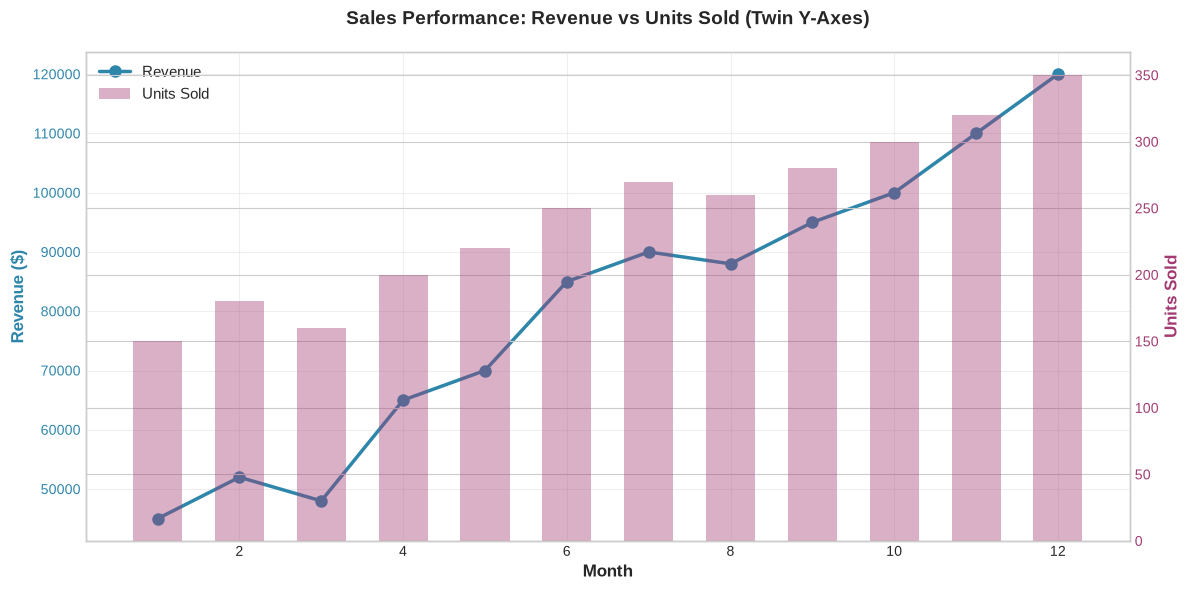

In [2]:
# Sample data: revenue and units sold
months = np.arange(1, 13)
revenue = np.array([45, 52, 48, 65, 70, 85, 90, 88, 95, 100, 110, 120]) * 1000
units = np.array([150, 180, 160, 200, 220, 250, 270, 260, 280, 300, 320, 350])

fig, ax1 = plt.subplots(figsize=(12, 6))

# First y-axis: Revenue
color1 = '#2E86AB'
ax1.set_xlabel('Month', fontsize=12, fontweight='bold')
ax1.set_ylabel('Revenue ($)', fontsize=12, fontweight='bold', color=color1)
line1 = ax1.plot(months, revenue, 'o-', color=color1, linewidth=2.5, 
                 markersize=8, label='Revenue')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Create second y-axis
ax2 = ax1.twinx()
color2 = '#A23B72'
ax2.set_ylabel('Units Sold', fontsize=12, fontweight='bold', color=color2)
line2 = ax2.bar(months, units, alpha=0.4, color=color2, label='Units Sold', width=0.6)
ax2.tick_params(axis='y', labelcolor=color2)

# Title
plt.title('Sales Performance: Revenue vs Units Sold (Twin Y-Axes)', 
          fontsize=14, fontweight='bold', pad=20)

# Combined legend
lines = line1 + [line2]
labels = [l.get_label() for l in line1] + ['Units Sold']
ax1.legend(lines, labels, loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

## 📊 2. Triple Axes (Three Y-Scales)

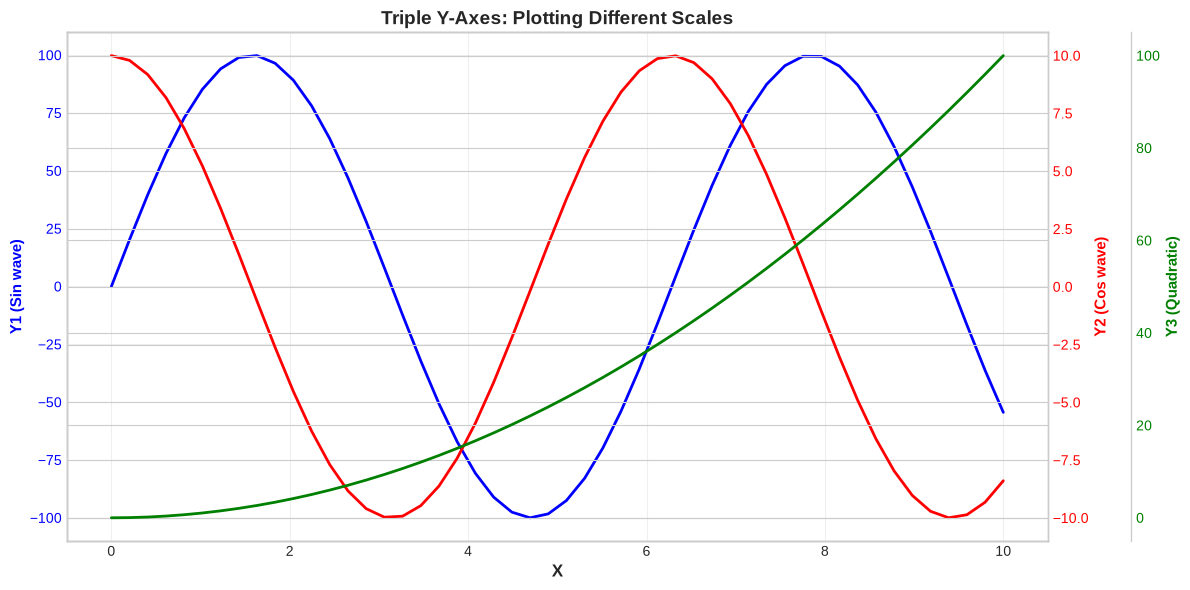

In [3]:
# Sample data
x = np.linspace(0, 10, 50)
y1 = 100 * np.sin(x)
y2 = 10 * np.cos(x)
y3 = x**2

fig, ax1 = plt.subplots(figsize=(12, 6))

# First axis
color1 = 'blue'
ax1.set_xlabel('X', fontsize=12, fontweight='bold')
ax1.set_ylabel('Y1 (Sin wave)', fontsize=11, color=color1, fontweight='bold')
ax1.plot(x, y1, color=color1, linewidth=2, label='100*sin(x)')
ax1.tick_params(axis='y', labelcolor=color1)

# Second axis
ax2 = ax1.twinx()
color2 = 'red'
ax2.set_ylabel('Y2 (Cos wave)', fontsize=11, color=color2, fontweight='bold')
ax2.plot(x, y2, color=color2, linewidth=2, label='10*cos(x)')
ax2.tick_params(axis='y', labelcolor=color2)

# Third axis (offset from the right)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
color3 = 'green'
ax3.set_ylabel('Y3 (Quadratic)', fontsize=11, color=color3, fontweight='bold')
ax3.plot(x, y3, color=color3, linewidth=2, label='x²')
ax3.tick_params(axis='y', labelcolor=color3)

plt.title('Triple Y-Axes: Plotting Different Scales', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🎯 3. Layered Plots: Line + Scatter + Bar

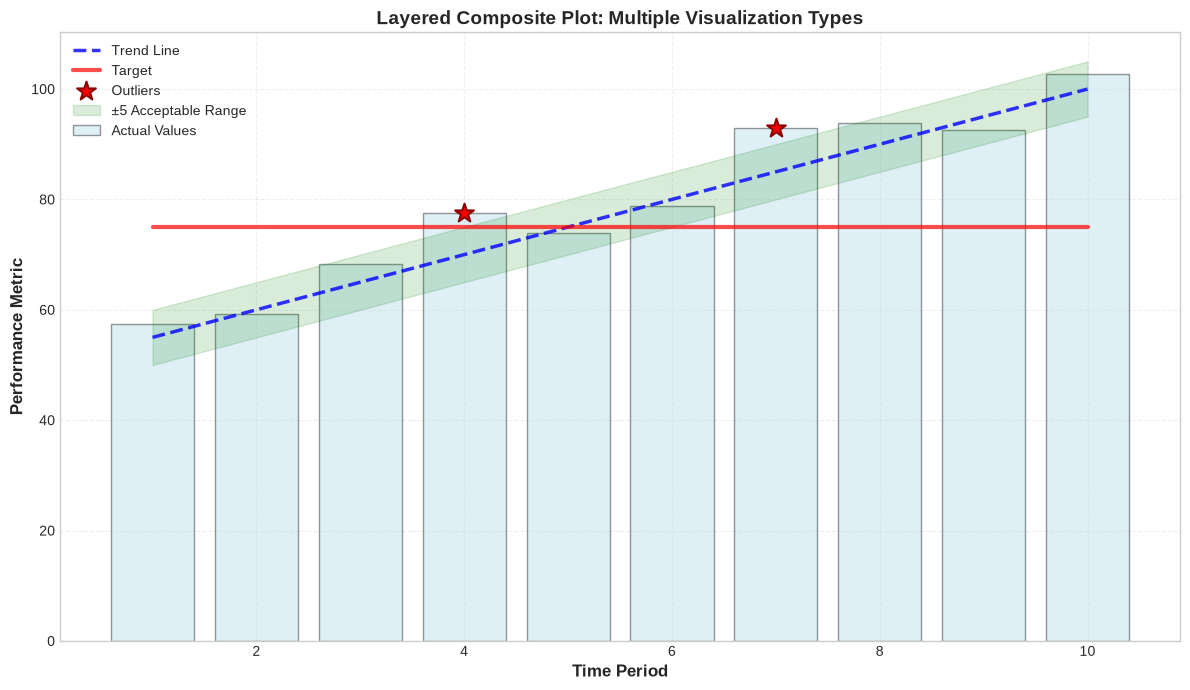

In [4]:
# Sample data
np.random.seed(42)
x = np.arange(1, 11)
trend = 50 + 5 * x
actual = trend + np.random.randn(10) * 5
target = np.full_like(x, 75)

fig, ax = plt.subplots(figsize=(12, 7))

# Bar chart (background layer)
bars = ax.bar(x, actual, alpha=0.4, color='lightblue', 
              edgecolor='black', linewidth=1, label='Actual Values')

# Trend line
ax.plot(x, trend, 'b--', linewidth=2.5, label='Trend Line', alpha=0.8)

# Target line
ax.plot(x, target, 'r-', linewidth=3, label='Target', alpha=0.7)

# Scatter points highlighting extremes
extremes_idx = np.where(np.abs(actual - trend) > 5)[0]
ax.scatter(x[extremes_idx], actual[extremes_idx], 
           s=200, c='red', marker='*', zorder=10, 
           label='Outliers', edgecolors='darkred', linewidth=1.5)

# Shaded region showing acceptable range
ax.fill_between(x, trend - 5, trend + 5, alpha=0.15, color='green', 
                label='±5 Acceptable Range')

ax.set_xlabel('Time Period', fontsize=12, fontweight='bold')
ax.set_ylabel('Performance Metric', fontsize=12, fontweight='bold')
ax.set_title('Layered Composite Plot: Multiple Visualization Types', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## 🔀 4. Shared Axes Across Subplots

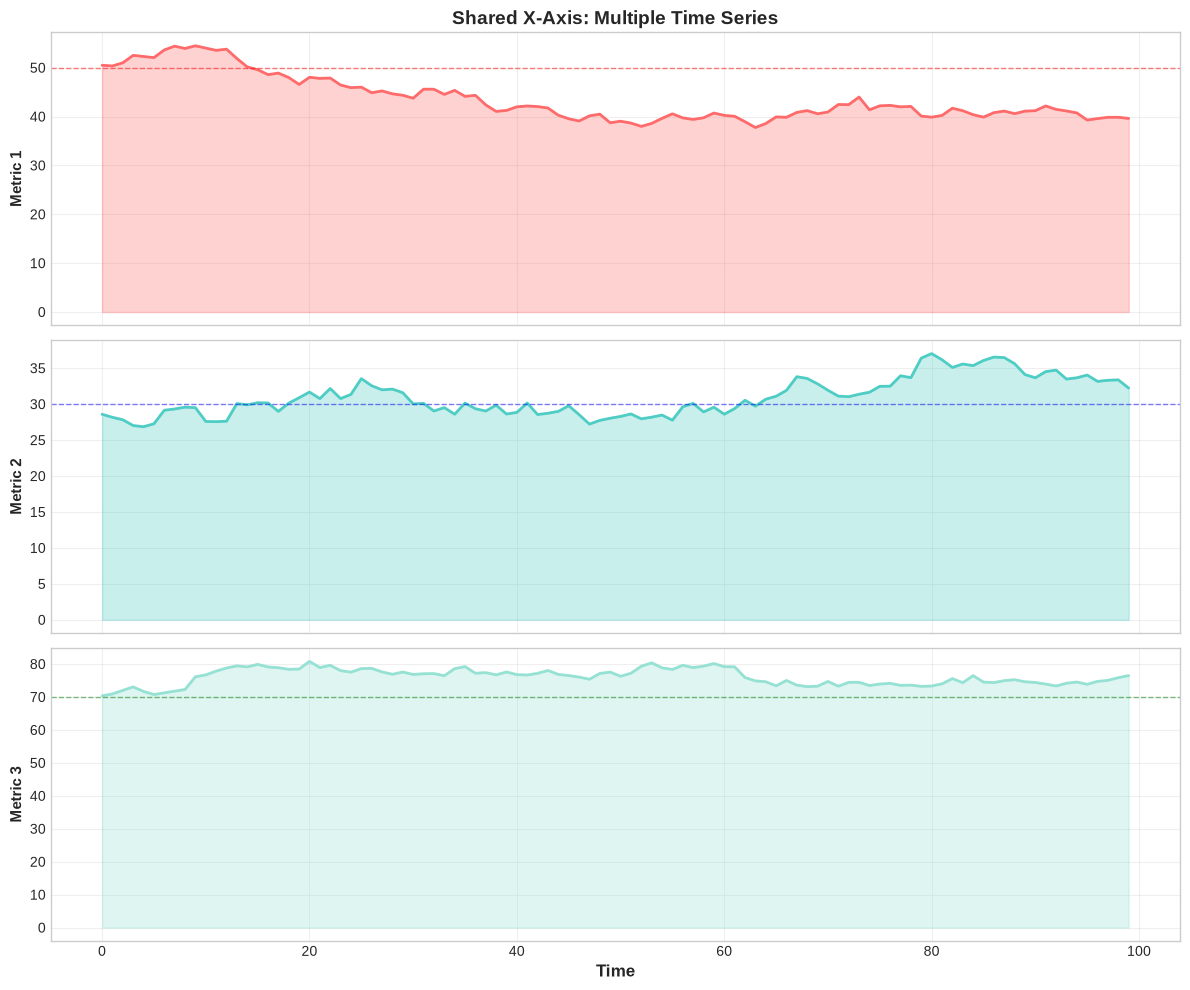

In [5]:
# Generate time series data for multiple metrics
np.random.seed(42)
x = np.arange(0, 100)
metric1 = np.cumsum(np.random.randn(100)) + 50
metric2 = np.cumsum(np.random.randn(100)) + 30
metric3 = np.cumsum(np.random.randn(100)) + 70

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot 1
ax1.plot(x, metric1, color='#FF6B6B', linewidth=2)
ax1.fill_between(x, metric1, alpha=0.3, color='#FF6B6B')
ax1.set_ylabel('Metric 1', fontsize=11, fontweight='bold')
ax1.set_title('Shared X-Axis: Multiple Time Series', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=50, color='red', linestyle='--', linewidth=1, alpha=0.5)

# Plot 2
ax2.plot(x, metric2, color='#4ECDC4', linewidth=2)
ax2.fill_between(x, metric2, alpha=0.3, color='#4ECDC4')
ax2.set_ylabel('Metric 2', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=30, color='blue', linestyle='--', linewidth=1, alpha=0.5)

# Plot 3
ax3.plot(x, metric3, color='#95E1D3', linewidth=2)
ax3.fill_between(x, metric3, alpha=0.3, color='#95E1D3')
ax3.set_ylabel('Metric 3', fontsize=11, fontweight='bold')
ax3.set_xlabel('Time', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.axhline(y=70, color='green', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

## 🔧 5. Broken Axis (Discontinuous Scale)

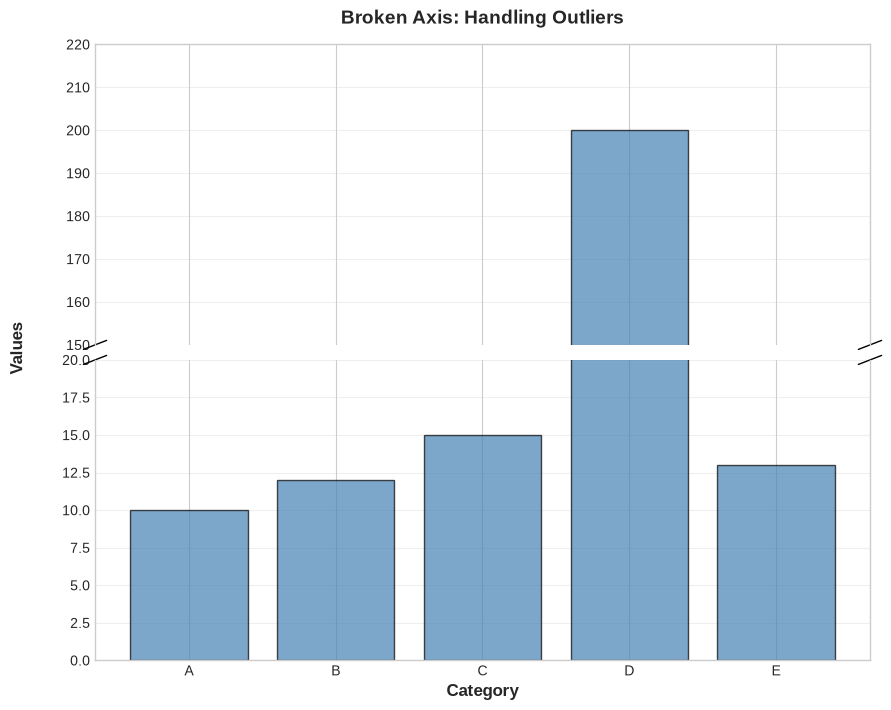

In [6]:
# Data with a large outlier
categories = ['A', 'B', 'C', 'D', 'E']
values = [10, 12, 15, 200, 13]

# Create two subplots with different y-ranges
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.subplots_adjust(hspace=0.05)

# Plot the same data on both axes
x_pos = np.arange(len(categories))
ax1.bar(x_pos, values, color='steelblue', alpha=0.7, edgecolor='black')
ax2.bar(x_pos, values, color='steelblue', alpha=0.7, edgecolor='black')

# Set different y-limits
ax1.set_ylim(150, 220)
ax2.set_ylim(0, 20)

# Hide spines between ax1 and ax2
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)
ax2.xaxis.tick_bottom()

# Add diagonal lines to show break
d = 0.015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1)
ax1.plot((-d, +d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# Labels
ax2.set_xticks(x_pos)
ax2.set_xticklabels(categories)
ax2.set_xlabel('Category', fontsize=12, fontweight='bold')
fig.text(0.04, 0.5, 'Values', va='center', rotation='vertical', 
         fontsize=12, fontweight='bold')
ax1.set_title('Broken Axis: Handling Outliers', fontsize=14, fontweight='bold', pad=15)

ax1.grid(True, alpha=0.3, axis='y')
ax2.grid(True, alpha=0.3, axis='y')

plt.show()

## 💼 6. Real-World Example: Financial Dashboard

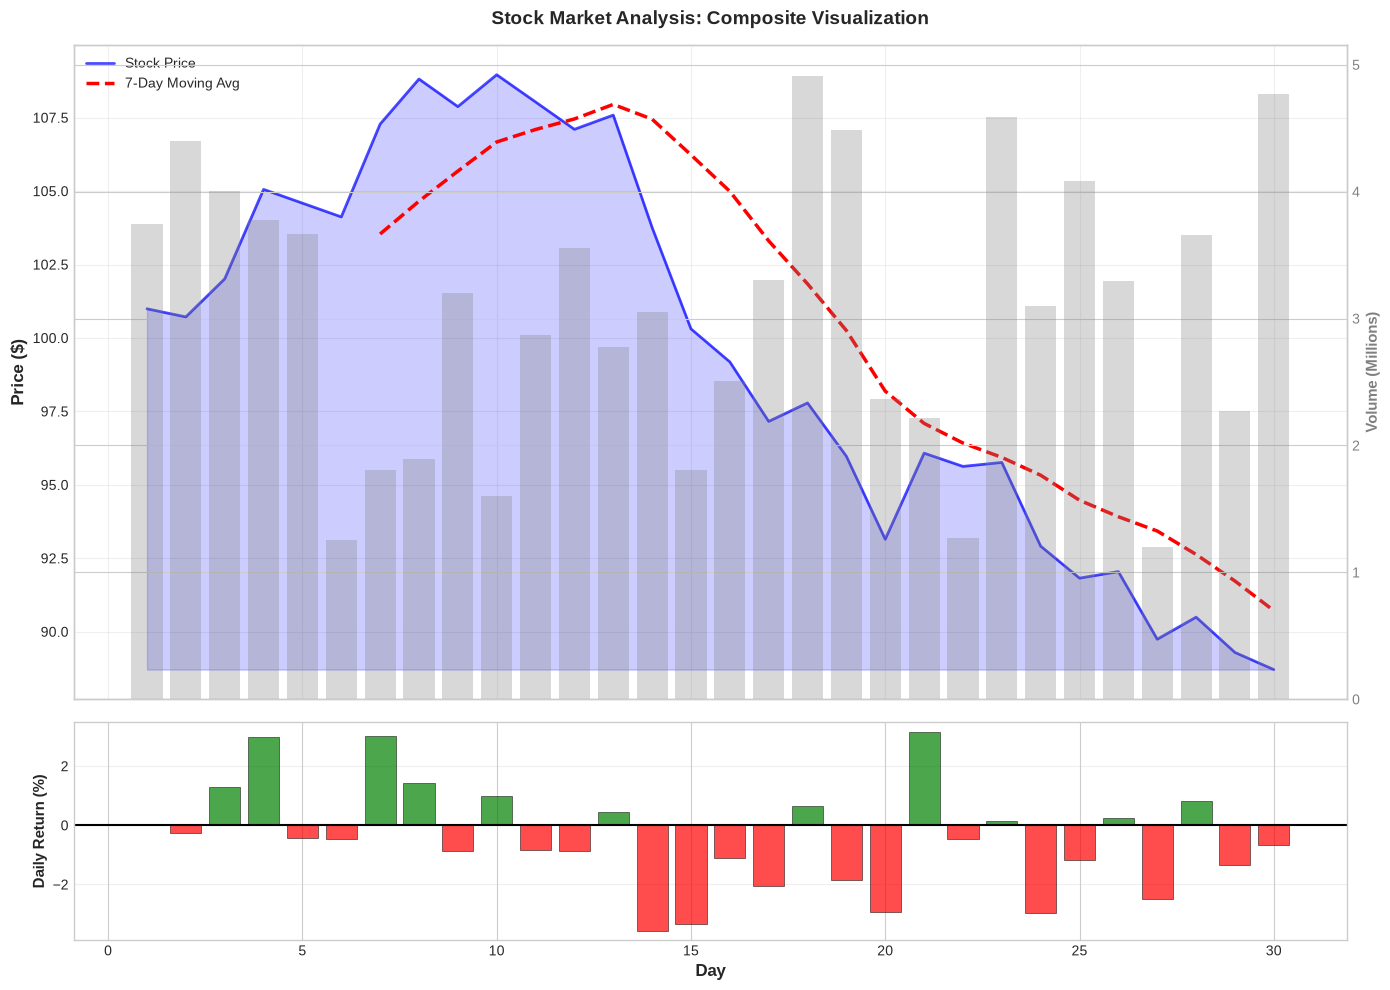

In [7]:
# Generate financial data
np.random.seed(42)
days = np.arange(1, 31)
stock_price = 100 + np.cumsum(np.random.randn(30) * 2)
volume = np.random.randint(1000000, 5000000, 30)
moving_avg = pd.Series(stock_price).rolling(window=7).mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), 
                               gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Top plot: Price with moving average
ax1.plot(days, stock_price, 'b-', linewidth=2, label='Stock Price', alpha=0.7)
ax1.plot(days, moving_avg, 'r--', linewidth=2.5, label='7-Day Moving Avg')
ax1.fill_between(days, stock_price, stock_price.min(), alpha=0.2, color='blue')

# Add volume as twin axis on top plot
ax1_twin = ax1.twinx()
ax1_twin.bar(days, volume/1000000, alpha=0.3, color='gray', width=0.8, label='Volume (M)')
ax1_twin.set_ylabel('Volume (Millions)', fontsize=11, color='gray', fontweight='bold')
ax1_twin.tick_params(axis='y', labelcolor='gray')

ax1.set_ylabel('Price ($)', fontsize=12, fontweight='bold')
ax1.set_title('Stock Market Analysis: Composite Visualization', 
              fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# Bottom plot: Daily returns
returns = np.diff(stock_price) / stock_price[:-1] * 100
colors = ['green' if r > 0 else 'red' for r in returns]
ax2.bar(days[1:], returns, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax2.set_xlabel('Day', fontsize=12, fontweight='bold')
ax2.set_ylabel('Daily Return (%)', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 🎯 Key Takeaways

- ✅ Use `twinx()` to create a second y-axis with different scale
- ✅ Layer multiple plot types (line, bar, scatter, fill)
- ✅ Share axes with `sharex=True` or `sharey=True` in subplots
- ✅ Broken axes help visualize data with outliers
- ✅ Color-code related data across twin axes
- ✅ Combine legends from multiple axes for clarity
- ✅ Use `zorder` to control layer stacking order

## 💡 Try It Yourself

1. Create financial charts with price and volume
2. Plot temperature and precipitation on same graph
3. Visualize multiple metrics with different scales
4. Build dashboards with shared time axes
5. Handle outliers with broken axes